# PyTorch Regression — Predict Diabetes Progression

## Learning goals

By the end, you will be able to:

1. explain what regression predicts;
2. split and scale data without leakage;
3. build an MLP with one numeric output;
4. train with MSE and AdamW;
5. use `ReduceLROnPlateau` correctly;
6. evaluate with MAE, RMSE, R², a prediction plot, and residuals.

## Dataset story

The built-in scikit-learn Diabetes dataset contains **442 patients**, **10 numeric features**, and one numeric target: a measure of disease progression one year after the baseline measurement.

```text
10 patient measurements → neural network → 1 predicted number
```

## 1. Regression versus classification

| Problem | Output example | Task type |
|---|---|---|
| predict tomorrow's temperature | `31.6°C` | regression |
| predict a house price | `₹42.5 lakh` | regression |
| predict spam or not spam | `0` or `1` | classification |
| predict one Iris species | class `0`, `1`, or `2` | classification |

In [1]:
# WHAT: Import the libraries and fix the random seed.
# WHY: The same seed makes the classroom run reproducible.
# OUTPUT: PyTorch version and the CPU device used for this small dataset.

import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")  # CPU is more than enough for 442 rows.
print("torch:", torch.__version__, "| device:", device)

torch: 2.12.0 | device: cpu


## 2. Load and understand the dataset

The target is a numeric progression score. It is useful for learning regression, but this classroom model is **not a medical diagnostic system**.

In [2]:
# WHAT: Load the real Diabetes regression dataset included with scikit-learn.
# WHY: We need to understand the input shape and target before choosing a model.
# OUTPUT: Row count, feature count, feature names, and target range.

diabetes = load_diabetes()
X_all = diabetes.data.astype("float32")
y_all = diabetes.target.astype("float32")

print("X shape:", X_all.shape)
print("y shape:", y_all.shape)
print("feature names:", diabetes.feature_names)
print("target min / mean / max:",
      round(y_all.min(), 1), round(y_all.mean(), 1), round(y_all.max(), 1))

X shape: (442, 10)
y shape: (442,)
feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
target min / mean / max: 25.0 152.1 346.0


## 3. Split first: train, validation, test

```text
TRAIN       updates model weights
VALIDATION  chooses settings and early-stopping point
TEST        final check after choices are complete
```

We use a `60% / 20% / 20%` split.

In [3]:
# WHAT: Make train, validation, and test sets.
# WHY: Each subset has a different job in an honest ML experiment.
# OUTPUT: 265 training rows, 88 validation rows, and 89 test rows.

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.40, random_state=SEED
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED
)

print("train:", X_train.shape, y_train.shape)
print("valid:", X_valid.shape, y_valid.shape)
print("test :", X_test.shape, y_test.shape)

train: (265, 10) (265,)
valid: (88, 10) (88,)
test : (89, 10) (89,)


## 4. Scale features without leakage

Features can have different ranges. Scaling helps the optimizer take balanced steps.

```text
fit scaler      → training features only
transform       → train, validation, and test
never re-fit    → on validation or test
```

In [4]:
# WHAT: Fit StandardScaler on training data, transform all splits, and create tensors.
# WHY: Training-only fitting prevents data leakage; tensors are required by PyTorch.
# OUTPUT: Float32 feature tensors and `(N, 1)` regression targets.

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train).astype("float32")
X_valid_s = scaler.transform(X_valid).astype("float32")
X_test_s = scaler.transform(X_test).astype("float32")

def to_float_tensor(array):
    return torch.tensor(array, dtype=torch.float32, device=device)

Xtr = to_float_tensor(X_train_s)
Xva = to_float_tensor(X_valid_s)
Xte = to_float_tensor(X_test_s)

ytr = to_float_tensor(y_train).view(-1, 1)
yva = to_float_tensor(y_valid).view(-1, 1)
yte = to_float_tensor(y_test).view(-1, 1)

print("X train:", Xtr.dtype, tuple(Xtr.shape))
print("y train:", ytr.dtype, tuple(ytr.shape))
print("train feature mean (approximately 0):", Xtr.mean(0)[:4])

X train: torch.float32 (265, 10)
y train: torch.float32 (265, 1)
train feature mean (approximately 0): tensor([ 1.7994e-09, -5.5781e-08,  1.7994e-09, -8.9969e-09])


## 5. Start with a baseline

A neural network is useful only if it beats a simple reference.

Our baseline always predicts the **mean training target**.

In [5]:
# WHAT: Evaluate a mean-prediction baseline on the test set.
# WHY: The neural network must improve on a simple reference model.
# OUTPUT: Baseline MAE and RMSE values for later comparison.

baseline_prediction = np.full_like(y_test, y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_prediction)
baseline_rmse = mean_squared_error(y_test, baseline_prediction) ** 0.5

print("baseline prediction:", round(float(y_train.mean()), 2))
print("baseline MAE :", round(baseline_mae, 2))
print("baseline RMSE:", round(baseline_rmse, 2))

baseline prediction: 151.03
baseline MAE : 66.73
baseline RMSE: 76.91


## 6. Build a small regression MLP

```text
10 input features
       │
       ▼
32 hidden neurons → ReLU
       │
       ▼
16 hidden neurons → ReLU
       │
       ▼
1 raw numeric prediction
```

The last layer has **one neuron** because regression predicts one number.

There is no sigmoid or softmax. Those functions are used to convert classification logits, not ordinary regression output.

In [6]:
# WHAT: Define a small MLP with one numeric output.
# WHY: Hidden layers can learn non-linear relationships between patient features and target.
# OUTPUT: Model structure, parameter count, and output shape `(4, 1)`.

class RegressionMLP(nn.Module):
    def __init__(self, in_features=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),  # one unrestricted number; no sigmoid or softmax
        )

    def forward(self, x):
        return self.net(x)

model = RegressionMLP().to(device)
print(model)
print("trainable parameters:", sum(p.numel() for p in model.parameters()))

with torch.inference_mode():
    sample_output = model(Xtr[:4])
print("output shape:", tuple(sample_output.shape))
print("first raw predictions:", sample_output.squeeze().tolist())

RegressionMLP(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)
trainable parameters: 897
output shape: (4, 1)
first raw predictions: [0.043282702565193176, 0.04943837225437164, 0.011315226554870605, -0.018573656678199768]


## 7. Choose a regression loss

| Loss | Meaning | Useful when |
|---|---|---|
| MSE | squares every error | large errors should receive strong penalty |
| MAE | absolute error | outliers should have less influence |
| Huber / Smooth L1 | MSE-like near zero, MAE-like far away | some outliers are expected |

Main training loss here: `nn.MSELoss()`.

In [7]:
# WHAT: Compare MSE, MAE, and Huber on three simple predictions.
# WHY: Seeing the values makes the loss behaviour easier to understand.
# OUTPUT: MSE penalizes the large error more strongly than MAE or Huber.

actual = torch.tensor([100.0, 200.0, 300.0])
predicted = torch.tensor([110.0, 160.0, 420.0])

print("errors:", (predicted - actual).tolist())
print("MSE  :", nn.MSELoss()(predicted, actual).item())
print("MAE  :", nn.L1Loss()(predicted, actual).item())
print("Huber:", nn.HuberLoss(delta=20.0)(predicted, actual).item())

errors: [10.0, -40.0, 120.0]
MSE  : 5366.66650390625
MAE  : 56.66666793823242
Huber: 950.0


## 8. Why this notebook uses `ReduceLROnPlateau`

```python
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=20
)
```

This Diabetes regression project does **not** know the best epoch in advance. We watch validation MSE:

```text
validation MSE improves → keep LR
validation MSE stays flat → reduce LR
```

That is why plateau scheduling fits this notebook. It responds to validation behaviour instead of following a pre-decided calendar.

### What if we use another scheduler?

| Choice | What would happen here? |
|---|---|
| `CosineAnnealingLR` | It could work, but LR would reduce based on a chosen epoch plan, not based on validation MSE. We would need to decide `T_max` first. |
| `OneCycleLR` | It could work after changing this lesson to mini-batches and finding a safe `max_lr`. This full-batch classroom run has only one update per epoch, so OneCycle is less natural here. |
| No scheduler | The model may still learn, but we must manually choose one LR that is suitable both early and late in training. |

In [8]:
# WHAT: Create the regression loss, AdamW optimizer, and plateau scheduler.
# WHY: Validation MSE, not a fixed epoch calendar, decides when LR should reduce.
# ALTERNATIVE: Cosine needs a planned T_max; OneCycle needs mini-batch steps and a tested max_lr.
# OUTPUT: Initial learning rate and scheduler configuration.

loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(), lr=1e-2, weight_decay=1e-3
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",       # smaller validation loss is better
    factor=0.5,       # new LR = old LR * 0.5
    patience=20,      # wait 20 non-improving epochs
    min_lr=1e-5,
)

print("initial learning rate:", optimizer.param_groups[0]["lr"])

initial learning rate: 0.01


## 9. The training loop

```text
model.train()
prediction = model(X_train)
loss = MSE(prediction, target)
optimizer.zero_grad()
loss.backward()
optimizer.step()

model.eval() + inference_mode()
validation loss
scheduler.step(validation loss)
save best model
```

This dataset is small, so we use one full batch to keep the code easy to read. For a large dataset, use a `DataLoader` and mini-batches.

In [9]:
# WHAT: Define a simple full-batch training loop with validation and early stopping.
# WHY: We need separate train/evaluation modes and must restore the best model state.
# OUTPUT: A history containing train loss, validation loss, and learning rate.

def train_regression(model, X_train, y_train, X_valid, y_valid,
                     optimizer, scheduler, loss_fn,
                     epochs=500, early_stop_patience=70):
    history = {"train": [], "valid": [], "lr": []}
    best_valid = float("inf")
    best_state = None
    best_epoch = 0
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        # ----- TRAIN -----
        model.train()
        train_prediction = model(X_train)
        train_loss = loss_fn(train_prediction, y_train)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        # ----- VALIDATE: no gradient and no weight update -----
        model.eval()
        with torch.inference_mode():
            valid_prediction = model(X_valid)
            valid_loss = loss_fn(valid_prediction, y_valid).item()

        # Reduce LR only after seeing the validation result.
        scheduler.step(valid_loss)

        history["train"].append(train_loss.item())
        history["valid"].append(valid_loss)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        # Save a real copy of the best weights.
        if valid_loss < best_valid - 1e-3:
            best_valid = valid_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch == 1 or epoch % 100 == 0:
            print(f"epoch {epoch:>3} | train MSE {train_loss.item():8.2f} "
                  f"| valid MSE {valid_loss:8.2f} "
                  f"| lr {optimizer.param_groups[0]['lr']:.5f}")

        if bad_epochs >= early_stop_patience:
            print("early stopping at epoch", epoch)
            break

    model.load_state_dict(best_state)
    print(f"restored epoch {best_epoch} with validation MSE {best_valid:.2f}")
    return history

In [10]:
# WHAT: Train the regression model.
# WHY: This runs all learning, validation, scheduling, and checkpoint steps together.
# OUTPUT: Progress lines and a populated training history.

history = train_regression(
    model, Xtr, ytr, Xva, yva,
    optimizer, scheduler, loss_fn,
    epochs=500,
)

epoch   1 | train MSE 28781.23 | valid MSE 26766.44 | lr 0.01000
epoch 100 | train MSE  3194.09 | valid MSE  3344.69 | lr 0.01000
epoch 200 | train MSE  2556.67 | valid MSE  2603.32 | lr 0.01000
epoch 300 | train MSE  2481.54 | valid MSE  2580.37 | lr 0.00500
epoch 400 | train MSE  2434.42 | valid MSE  2558.26 | lr 0.00250
epoch 500 | train MSE  2424.71 | valid MSE  2557.51 | lr 0.00016
restored epoch 500 with validation MSE 2557.51


## 10. Read the loss and learning-rate curves

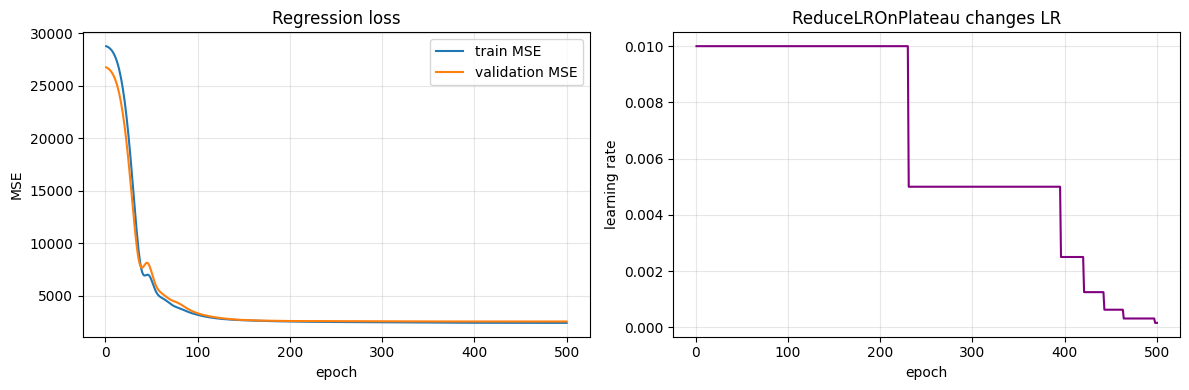

In [11]:
# WHAT: Plot train loss, validation loss, and learning rate.
# WHY: Curves help us diagnose learning, overfitting, and scheduler behaviour.
# OUTPUT: Two small classroom-friendly plots.

epochs_run = range(1, len(history["train"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_run, history["train"], label="train MSE")
axes[0].plot(epochs_run, history["valid"], label="validation MSE")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Regression loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_run, history["lr"], color="purple")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("learning rate")
axes[1].set_title("ReduceLROnPlateau changes LR")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Final regression metrics

| Metric | Easy meaning |
|---|---|
| MAE | average absolute prediction error; lower is better |
| RMSE | like MAE but punishes large errors more; lower is better |
| R² | improvement over predicting the mean; `1` is ideal, `0` matches a mean baseline |

Do not use classification accuracy for a regression target.

In [12]:
# WHAT: Evaluate the restored best model on the test set exactly once.
# WHY: MAE, RMSE, and R² describe different parts of regression quality.
# OUTPUT: Test metrics and a comparison with the mean baseline.

model.eval()
with torch.inference_mode():
    test_prediction = model(Xte).squeeze(1).cpu().numpy()

test_mae = mean_absolute_error(y_test, test_prediction)
test_rmse = mean_squared_error(y_test, test_prediction) ** 0.5
test_r2 = r2_score(y_test, test_prediction)

print("MEAN BASELINE")
print("  MAE :", round(baseline_mae, 2))
print("  RMSE:", round(baseline_rmse, 2))

print("\nNEURAL NETWORK")
print("  MAE :", round(test_mae, 2))
print("  RMSE:", round(test_rmse, 2))
print("  R²  :", round(test_r2, 3))

MEAN BASELINE
  MAE : 66.73
  RMSE: 76.91

NEURAL NETWORK
  MAE : 45.98
  RMSE: 56.15
  R²  : 0.455


## 12. Prediction plot and residuals

- **Prediction plot:** points near the diagonal are better.
- **Residual:** `actual - predicted`.
- A random cloud around zero is healthier than a visible pattern.

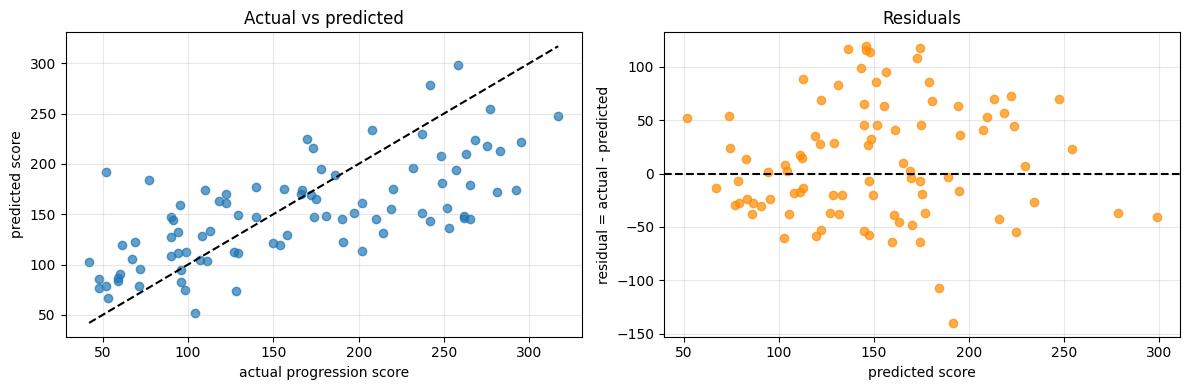

In [13]:
# WHAT: Plot predicted versus actual values and the residual errors.
# WHY: Metrics give one number; plots reveal patterns and systematic mistakes.
# OUTPUT: A diagonal prediction plot and a residual plot around zero.

residuals = y_test - test_prediction

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, test_prediction, alpha=0.7)
low = min(y_test.min(), test_prediction.min())
high = max(y_test.max(), test_prediction.max())
axes[0].plot([low, high], [low, high], "--", color="black")
axes[0].set_xlabel("actual progression score")
axes[0].set_ylabel("predicted score")
axes[0].set_title("Actual vs predicted")
axes[0].grid(alpha=0.3)

axes[1].scatter(test_prediction, residuals, alpha=0.7, color="darkorange")
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set_xlabel("predicted score")
axes[1].set_ylabel("residual = actual - predicted")
axes[1].set_title("Residuals")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# WHAT: Show a few individual test predictions.
# WHY: Concrete examples are easier to explain than only aggregate metrics.
# OUTPUT: Actual value, predicted value, and signed error for five patients.

print(f"{'actual':>8} {'predicted':>10} {'error':>10}")
for actual_value, predicted_value in zip(y_test[:5], test_prediction[:5]):
    error = predicted_value - actual_value
    print(f"{actual_value:8.1f} {predicted_value:10.1f} {error:10.1f}")

  actual  predicted      error
   275.0      218.2      -56.8
    52.0       79.1       27.1
   237.0      229.6       -7.4
   140.0      176.7       36.7
   110.0      174.4       64.4


## 13. Common mistakes

| Mistake | Why it is wrong |
|---|---|
| final layer has 3 outputs | this problem needs one numeric output |
| sigmoid after final layer | it forces output between 0 and 1 |
| target shape `(N,)` while prediction is `(N,1)` | broadcasting can silently produce the wrong loss |
| scaler fitted on all rows | validation/test information leaks into training |
| reporting only MSE | squared units are difficult to explain; add MAE/RMSE/R² |
| calling `ReduceLROnPlateau.step()` without a metric | this scheduler needs the monitored validation value |

> **Remember:** regression predicts a number; classification predicts a class.

## 14. Practice

Try these one at a time:

1. Change hidden sizes from `32 → 16` to `16 → 8`.
2. Replace `MSELoss` with `HuberLoss(delta=20.0)`.
3. Change plateau `patience` from `20` to `8`.
4. Compare validation curves and final test MAE.

## 15. Recap

```text
TASK       regression → predict one continuous number
MODEL      10 inputs → hidden layers → 1 unrestricted output
LOSS       MSE for training; MAE/RMSE/R² for explanation
OPTIMIZER  AdamW updates weights
SCHEDULER  ReduceLROnPlateau watches validation loss
HONESTY    fit scaler on train only; use test after choices are fixed
```